<SPAN> <BR>Load the dataframe<BR>
Set the index to the base_date_time. Your index should be a DateTimeIndex<br>
Clean the data: we don't want any row where the sog is null<br>
First Analysis: When are boats out? Display a line graph where your x-axis is the hour of the day, and the y-axis is the number of unique vessels out at that hour. Hint: the MMSI column is a great way to identity a unique vessel. What time (UTC) saw the most boats out on the water? And the least? Does this track with what you could expect?<br>
Second Analysis: let's look at a specific boat, the Henry Hudson (MMSI: 366651000). The owner of the boat has asked us how long the boat engines were active for that day. To get to this, you must: <br>
 a) Figure out when the boat was "accelerating". Create a column called "acceleration", which is going to be the difference between each "sog". Hints: to achieve this, use the "diff()" function on your column. Be sure that your index is sorted, meaning the rows are sorted by time (.sort_index() is very helpful for this)<br>
 b) Once you have a column "acceleration" and "duration", we can assume that the boat engines were active if the "acceleration" is greater than 0. Filter your dataframe to only have rows where the acceleration is positive.<br>
 c) Sum up the "duration" column to see how long the engines were active for that day. This will allow us to answer the boat captain<br><br>
<b>Bonus: create a function that takes the MMSI as a parameter, and return the active engine time for that day. Name this function calculate_total_active_engine_time. <b>

<h1>LIBRARIES</h1>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h1>Load the dataframe</h1>

In [2]:
url = 'https://noaaocm.blob.core.windows.net/ais/csv2/csv2025/ais-2025-01-08.csv.zst'
noaa = pd.read_csv(url)

<h1>Evaluate uniqueness</h1>

In [3]:
noaa.columns

Index(['mmsi', 'base_date_time', 'longitude', 'latitude', 'sog', 'cog',
       'heading', 'vessel_name', 'imo', 'call_sign', 'vessel_type', 'status',
       'length', 'width', 'draft', 'cargo', 'transceiver'],
      dtype='object')

<h1>Set the index to the base_date_time. Your index should be a DateTimeIndex</h1>

In [4]:
noaa['base_date_time'] = pd.to_datetime(noaa['base_date_time'])
noaa.dtypes

,0
mmsi,int64
base_date_time,datetime64[ns]
longitude,float64
latitude,float64
sog,float64
cog,float64
heading,float64
vessel_name,object
imo,object
call_sign,object


In [5]:
#CREATING COPY TO AVOID LOADING DATA IN CASE SOMETHING GOES WRONG
dfnoaa = noaa
dfnoaa = dfnoaa.set_index('base_date_time')

In [6]:
dfnoaa.head(3)

,mmsi,longitude,latitude,sog,cog,heading,vessel_name,imo,call_sign,vessel_type,status,length,width,draft,cargo,transceiver
base_date_time,,,,,,,,,,,,,,,,
2025-01-08 00:00:00,367793030,-122.40506,47.68588,4.6,155.5,NaN,WN1622SL,NaN,WDJ5962,37.0,NaN,10.0,3.0,NaN,NaN,B
2025-01-08 00:00:00,338160209,-119.69199,34.40719,0.0,106.3,NaN,WESTERLY,NaN,NaN,36.0,NaN,11.0,4.0,NaN,NaN,B
2025-01-08 00:00:01,266283000,-74.24126,38.41834,15.5,187.9,190.0,OBERON,IMO9377509,SKJF,70.0,0.0,237.0,32.0,9.1,70.0,A


In [7]:
noaa.shape

(5929631, 17)

<h1>Clean the data: we don't want any row where the sog is null</h1>

In [8]:
dfnoaa = dfnoaa[dfnoaa['sog'].notnull()] #use of notnull instead f isnull

In [9]:
dfnoaa.shape

(5917091, 16)

<h3>Getting rid of 12540 rows because have NULL as sog</h3>

<h1>First Analysis: When are boats out? Display a line graph where your x-axis is the hour of the day, and the y-axis is the number of unique vessels out at that hour. Hint: the MMSI column is a great way to identity a unique vessel. What time (UTC) saw the most boats out on the water? And the least? Does this track with what you could expect?</h1>

In [10]:
dfnoaa['hour'] = dfnoaa.index.hour

Text(0, 0.5, 'Unique Vessels (MMSI)')

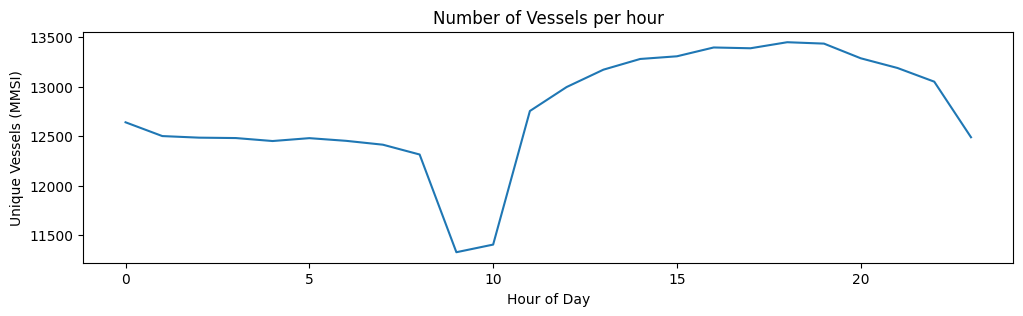

In [11]:
plt.figure(figsize=(12,3))
dfnoaa.groupby('hour')['mmsi'].nunique().plot()
plt.title('Number of Vessels per hour')
plt.xlabel('Hour of Day')
plt.ylabel('Unique Vessels (MMSI)')

<span>Based on the line plot I would say that the result is expected due that it shows that during nigth time traffic reduces significantly. However, something that I didnt expected was the significant decrease during 9 to 10 period. In my opinion it migth be due that at that time vessel arrive or depart from ports.

<h1>Second Analysis: let's look at a specific boat, the Henry Hudson (MMSI: 366651000). The owner of the boat has asked us how long the boat engines were active for that day. To get to this, you must:</h1>

<h2>a) Figure out when the boat was "accelerating". Create a column called "acceleration", which is going to be the difference between each "sog". Hints: to achieve this, use the "diff()" function on your column. Be sure that your index is sorted, meaning the rows are sorted by time (.sort_index() is very helpful for this)</h2>

In [12]:
henryhudson = dfnoaa[dfnoaa['mmsi'] ==366651000]

In [13]:
henryhudson['acceleration'] = henryhudson['sog'].diff()
henryhudson['duration'] = henryhudson.index.diff()
henryhudson.head()

/tmp/ipykernel_32884/1447301390.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  henryhudson['acceleration'] = henryhudson['sog'].diff()
/tmp/ipykernel_32884/1447301390.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  henryhudson['duration'] = henryhudson.index.diff()


,mmsi,longitude,latitude,sog,cog,heading,vessel_name,imo,call_sign,vessel_type,status,length,width,draft,cargo,transceiver,hour,acceleration,duration
base_date_time,,,,,,,,,,,,,,,,,,,
2025-01-08 00:00:04,366651000,-74.02250,40.75867,0.0,283.6,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,0,NaN,NaT
2025-01-08 00:01:14,366651000,-74.02209,40.75843,5.5,129.9,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,0,5.5,0 days 00:01:10
2025-01-08 00:02:45,366651000,-74.01930,40.75736,11.2,114.7,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,0,5.7,0 days 00:01:31
2025-01-08 00:05:06,366651000,-74.01090,40.76075,11.8,61.2,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,0,0.6,0 days 00:02:21
2025-01-08 00:06:45,366651000,-74.00498,40.76105,6.5,95.2,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,0,-5.3,0 days 00:01:39


<h2>b) Once you have a column "acceleration" and "duration", we can assume that the boat engines were active if the "acceleration" is greater than 0. Filter your dataframe to only have rows where the acceleration is positive.</h2>

<span>When acceleration becomes negative means that the engines were turned off and the ship is lossing power

In [14]:
hours_turned_on = henryhudson[henryhudson['acceleration'] >= 0]['duration'].sum()

In [15]:
hours_turned_off = henryhudson[henryhudson['acceleration'] < 0]['duration'].sum()

<h2>c) Sum up the "duration" column to see how long the engines were active for that day. This will allow us to answer the boat captain</h2>

In [16]:
print(f"The total hours that the ship {henryhudson['vessel_name'].iloc[0]} with mmsi {henryhudson['mmsi'].iloc[0]} had its engines actived was {hours_turned_on} hours")

The total hours that the ship HENRY HUDSON with mmsi 366651000 had its engines actived was 0 days 15:02:16 hours


<H1>FUNCTION CREATION</H1>

<h2>Bonus: create a function that takes the MMSI as a parameter, and return the active engine time for that day. Name this function calculate_total_active_engine_time. </h2>

In [22]:
def engine_on_time(mmsi):

    vessel = dfnoaa[dfnoaa['mmsi'] == mmsi].sort_index().copy()
    if vessel.empty:
        return 0, vessel

    vessel['acceleration'] = vessel['sog'].diff()
    vessel['duration'] = vessel.index.to_series().diff()

    total_time = vessel[vessel['acceleration'] >= 0]['duration'].sum()

    total_hours = total_time.total_seconds() / 3600

    return total_hours, vessel

In [23]:
mmsi_number = int(input('Enter the MMSI number of the vessel: '))
hours, vessel = engine_on_time(mmsi_number)

if vessel.empty:
    print("No vessel found with that MMSI")
else:
    print(f"""
    The vessel {vessel['vessel_name'].iloc[0]}
    with MMSI {mmsi_number}
    had its engines ON for approximately {hours:.2f} hours
    """)

Enter the MMSI number of the vessel: 366651000

    The vessel HENRY HUDSON 
    with MMSI 366651000 
    had its engines ON for approximately 16.94 hours
    
